In [47]:
import cfgrib
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## Prepare a datafile for Anemoi
CERRA data is on a Lambert Conformal Conic (LCC) projected grid, not regular lat/lon.

In [ ]:
datasets = cfgrib.open_datasets(
    "CERRA5.grib",
    backend_kwargs={"indexpath": "", "decode_timedelta": True},
)

### Bound to BOZ 

In [9]:
#Select only a box around the BOZ
def index_box(ds, lat_min=51, lat_max=52, lon_min=2.0, lon_max=4):
    lat = ds["latitude"].values   # 2-D (y, x)
    lon = ds["longitude"].values  # 2-D (y, x)

    m = (lat >= lat_min) & (lat <= lat_max) & (lon >= lon_min) & (lon <= lon_max)
    yy, xx = np.where(m)
    y0, y1 = int(yy.min()), int(yy.max())
    x0, x1 = int(xx.min()), int(xx.max())
    return slice(y0, y1 + 1), slice(x0, x1 + 1)

cropped = []
for ds in datasets:
    ys, xs = index_box(ds)
    dsc = ds.isel(y=ys, x=xs)  # hard crop, no masking → no NaNs

    if "heightAboveGround" in dsc.coords and dsc.coords["heightAboveGround"].size == 1:
        dsc = dsc.reset_coords("heightAboveGround", drop=True)
        dsc=dsc.squeeze()

    cropped.append(dsc)

In [10]:
aligned = xr.align(*cropped, join="inner")  # keep only common coords (e.g., time)
ds = xr.merge(aligned, compat="override", combine_attrs="drop")

### Add 100m wind speed and wind power via power curve
Add wind speed at 100m by extrapolating 
(Olaofe, Z. O. (2016). A surface-layer wind speed correction: A case-study of Darling station. Renewable Energy, 93, 228-244.)

In [11]:
#Compute 100 m wind speed (Olaofe 2016), keep dtype like the others, no attrs
w10=ds['si10']
alpha = 0.143
ws100 = (w10 * (100.0 / 10.0) ** alpha).astype(w10.dtype)
ws100 = ws100.rename("ws100")
ws100.attrs = {}  
ds = ds.assign(ws100=ws100)

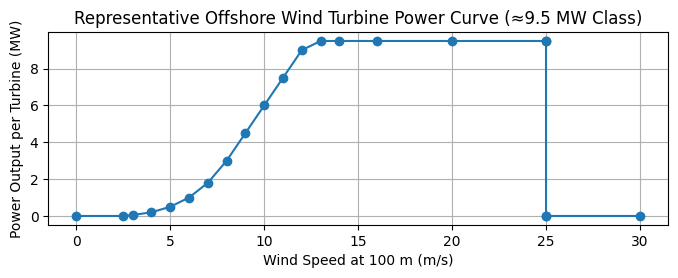

In [26]:
#add synthetic wind power with a power curve 
ws_pts = np.array([0.0, 2.5, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0,
                   11.0, 12.0, 13.0, 14.0, 16.0, 20.0, 24.99,24.999,25.0,25.01, 30.0], dtype="float32")
p_pts  = np.array([0.0, 0.0, 0.05, 0.20, 0.50, 1.00, 1.80, 3.00, 4.50, 6.00,
                   7.50, 9.00, 9.50, 9.50, 9.50, 9.50, 9.5,9.5,0.00,0.00, 0.00], dtype="float32")
plt.figure(figsize=(8, 2.5))
plt.plot(ws_pts, p_pts, marker='o', linestyle='-')
plt.xlabel("Wind Speed at 100 m (m/s)")
plt.ylabel("Power Output per Turbine (MW)")
plt.title("Representative Offshore Wind Turbine Power Curve (≈9.5 MW Class)")
plt.grid(True)
plt.show()

In [27]:
def interp_power(ws):
    return np.interp(ws, ws_pts, p_pts)

In [28]:
wind_power = xr.apply_ufunc(
    np.interp,                          # call NumPy directly
    ds["ws100"],
    kwargs={"xp": ws_pts, "fp": p_pts, "left": 0.0, "right": 0.0},
    input_core_dims=[[]],
    output_core_dims=[[]],
    vectorize=True,                     
    dask="parallelized",               
    output_dtypes=[ds["ws100"].dtype],  
).rename("wind_power")
wind_power.attrs = {}

ds = ds.assign(wind_power=wind_power)

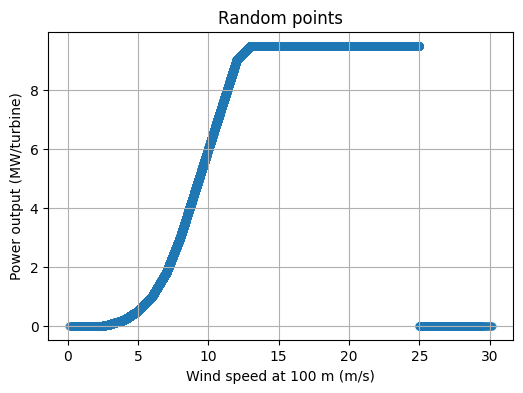

In [29]:
#SANITY CHECK
x=ds["ws100"].isel(time=slice(0,500)).isel(y=slice(0,10)).isel(x=slice(0,10))
y=ds["wind_power"].isel(time=slice(0,500)).isel(y=slice(0,10)).isel(x=slice(0,10))
ws_flat = x.values.ravel()
wp_flat = y.values.ravel()
mask = np.isfinite(ws_flat) & np.isfinite(wp_flat)
ws_flat = ws_flat[mask]; wp_flat = wp_flat[mask]

rng = np.random.default_rng(42)
n = min(100, ws_flat.size)
idx = rng.choice(ws_flat.size, size=n, replace=False)

# ---- plot ----
plt.figure(figsize=(6,4))
plt.scatter(ws_flat, wp_flat, s=25, alpha=0.7)
plt.xlabel("Wind speed at 100 m (m/s)")
plt.ylabel("Power output (MW/turbine)")
plt.title(f"Random points")
plt.grid(True)
plt.show()

In [30]:
#sanity check
nan_counts = {var: ds[var].isnull().sum().item() for var in ds.data_vars}
print(nan_counts)

{'mcc': 0, 't2m': 0, 'si10': 0, 'wdir10': 0, 'msl': 0, 'sr': 0, 'orog': 0, 'ws100': 0, 'wind_power': 0}


In [39]:
#Add sin and cosine of wind direction (at 10m) and sin and cosine of julian day 
dir_rad = np.deg2rad(ds["wdir10"])
sinwdir10 = np.sin(dir_rad).astype("float32").rename("sinwdir10")
coswdir10 = np.cos(dir_rad).astype("float32").rename("coswdir10")
year = ds["time"].dt.year
#2024 was a leap year
is_leap = ( (year % 4 == 0) )
year_len = xr.where(is_leap, 366, 365)

theta_doy = 2.0 * np.pi * (ds["time"].dt.dayofyear - 1) / year_len
sin_doy_1d = np.sin(theta_doy).astype("float32").rename("sin_doy")
cos_doy_1d = np.cos(theta_doy).astype("float32").rename("cos_doy")
sin_doy = sin_doy_1d.broadcast_like(ds["si10"])
cos_doy = cos_doy_1d.broadcast_like(ds["si10"])

ds = ds.assign(
    sinwdir10=sinwdir10,
    coswdir10=coswdir10,
    sin_doy=sin_doy,
    cos_doy=cos_doy,
)

In [41]:
ds.to_netcdf(
    "CERRA5_Belgium.nc",
    engine="netcdf4"
)

In [42]:
ds=xr.open_dataset("CERRA5_Belgium.nc")

In [50]:
def plot_cerra_domain_with_belgium_box(
    ds, lat_min=51, lat_max=52, lon_min=2.0, lon_max=4.0,
    extent=(-5, 5, 45, 55)
):
    lat = ds["latitude"].values
    lon = ds["longitude"].values

    # Wrap longitudes to [-180, 180] for plotting only
    lon_plot = ((lon + 180) % 360) - 180

    fig = plt.figure(figsize=(8, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines(resolution="10m")
    ax.gridlines(draw_labels=True, linestyle=":", linewidth=0.5)

    # Add country borders
    ax.add_feature(cfeature.BORDERS, linewidth=0.8)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)

    # Add Belgium outline specifically (from Natural Earth)
    countries = cfeature.NaturalEarthFeature(
        category="cultural",
        name="admin_0_countries",
        scale="10m",
        facecolor="none"
    )
    ax.add_feature(countries, edgecolor="gray", linewidth=0.5)

    # Plot CERRA grid outline
    ax.plot(lon_plot[0, :],  lat[0, :],  transform=ccrs.PlateCarree(), color="black", lw=1)
    ax.plot(lon_plot[-1, :], lat[-1, :], transform=ccrs.PlateCarree(), color="black", lw=1)
    ax.plot(lon_plot[:, 0],  lat[:, 0],  transform=ccrs.PlateCarree(), color="black", lw=1)
    ax.plot(lon_plot[:, -1], lat[:, -1], transform=ccrs.PlateCarree(), color="black", lw=1)

    # Belgium box
    rect = mpatches.Rectangle(
        (lon_min, lat_min),
        lon_max - lon_min,
        lat_max - lat_min,
        fill=False, linewidth=2, edgecolor="red",
        transform=ccrs.PlateCarree()
    )
    ax.add_patch(rect)

    ax.set_title("CERRA Grid Outline with Belgium and Custom Box")
    plt.show()


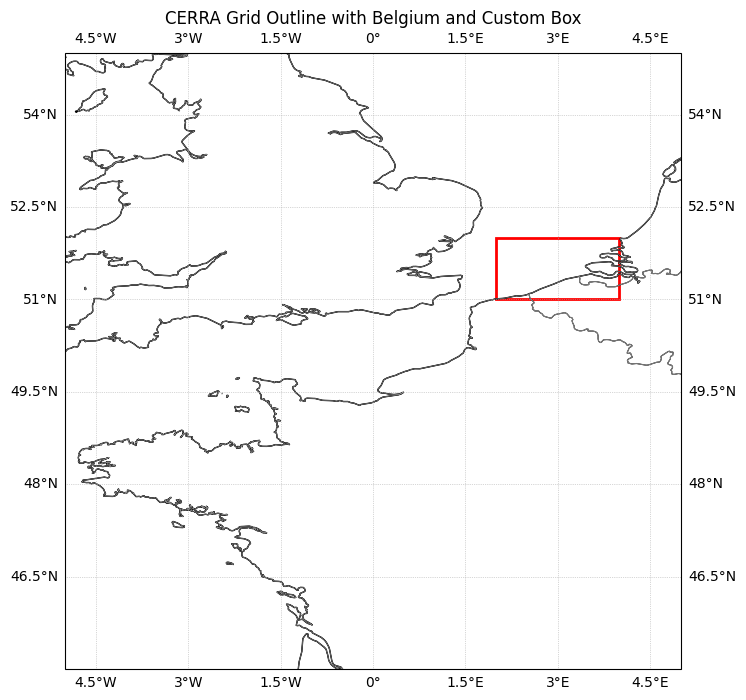

In [51]:
plot_cerra_domain_with_belgium_box(datasets[0])